Notebook onde contem toda a modelagem bruta, afim de realizar o treino, predicao, validacao e testes

In [2]:
import pandas as pd

In [3]:
df = pd.read_parquet(f"..\data\dados_anp_modelado.parquet") 

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ferna\AppData\Local\Temp\ipykernel_15920\542958505.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_parquet(f"..\data\dados_anp_modelado.parquet")


### Validando dados (média, mediana e desvio padrao em cima da var target (price_sale_median)) e analisando a correlação das variaveis exogenas com base no dolar

In [4]:
df.index = df["dt_week"]

In [5]:
df_train = df[(df.index.year <= 2024) & (df.index.month <= 12)]
df_val = df[(df.index.year == 2025) & (df.index.month <= 8)]
df_test = df[((df.index.year >= 2025) & (df.index.month >= 9)) | 
                   ((df.index.year >= 2026) & (df.index.month <= 8))]

In [6]:
dataframes = {
    "Treino": df_train,
    "Validação": df_val,
    "Teste": df_test
}

for nome, _df in dataframes.items():
    print(f"\n--- Base de {nome} ---")
    
    # Observe o uso de aspas simples ('') dentro dos colchetes 
    # para não conflitar com as aspas duplas ("") da f-string
    print(f"MÉDIA:\n{_df.groupby(['Produto'])['price_sale_median'].mean()}\n")
    print(f"MEDIANA:\n{_df.groupby(['Produto'])['price_sale_median'].median()}\n")
    print(f"STD:\n{_df.groupby(['Produto'])['price_sale_median'].std()}\n")


--- Base de Treino ---
MÉDIA:
Produto
DIESEL       3.499361
ETANOL       3.145188
GASOLINA     4.012453
GLP         64.609222
Name: price_sale_median, dtype: float64

MEDIANA:
Produto
DIESEL       3.075
ETANOL       2.990
GASOLINA     3.724
GLP         57.000
Name: price_sale_median, dtype: float64

STD:
Produto
DIESEL       1.494096
ETANOL       1.097850
GASOLINA     1.295616
GLP         27.267846
Name: price_sale_median, dtype: float64


--- Base de Validação ---
MÉDIA:
Produto
DIESEL        6.296175
ETANOL        4.753233
GASOLINA      6.417825
GLP         111.173497
Name: price_sale_median, dtype: float64

MEDIANA:
Produto
DIESEL        6.235
ETANOL        4.790
GASOLINA      6.370
GLP         110.000
Name: price_sale_median, dtype: float64

STD:
Produto
DIESEL       0.444013
ETANOL       0.400445
GASOLINA     0.395506
GLP         10.274565
Name: price_sale_median, dtype: float64


--- Base de Teste ---
MÉDIA:
Produto
DIESEL        6.582820
ETANOL        4.907311
GASOLINA      6.5

In [7]:
from scipy.stats import spearmanr

for i in range(2):
    if i == 0: periodo = 2015
    else: periodo = 2016
    print("PERIODO ANALISADO:", periodo)
    for produto in ['GASOLINA', 'ETANOL', 'DIESEL', 'GLP']:
        if periodo == 2015: dados = df[(df['Produto'] == produto) & (df.index.year <= 2015)]
        else: dados = df[(df['Produto'] == produto) & (df.index.year >= 2016)]
        print(f"\n{produto}")
        for col in ['Valor Venda Dolar', 'Close_BZ=F', 'ipca', 'selic', 'pib_mensal']:
            rho, p = spearmanr(dados['price_sale_median'], dados[col])
            sig = "✓" if p < 0.05 else "✗"
            print(f"  {col:<20} rho={rho:+.3f}  p={p:.4f}  {sig}")

PERIODO ANALISADO: 2015

GASOLINA
  Valor Venda Dolar    rho=+0.491  p=0.0000  ✓
  Close_BZ=F           rho=-0.058  p=0.0000  ✓
  ipca                 rho=+0.135  p=0.0000  ✓
  selic                rho=-0.014  p=0.1602  ✗
  pib_mensal           rho=+0.663  p=0.0000  ✓

ETANOL
  Valor Venda Dolar    rho=+0.384  p=0.0000  ✓
  Close_BZ=F           rho=+0.075  p=0.0000  ✓
  ipca                 rho=+0.157  p=0.0000  ✓
  selic                rho=-0.082  p=0.0000  ✓
  pib_mensal           rho=+0.637  p=0.0000  ✓

DIESEL
  Valor Venda Dolar    rho=+0.641  p=0.0000  ✓
  Close_BZ=F           rho=-0.230  p=0.0000  ✓
  ipca                 rho=+0.064  p=0.0000  ✓
  selic                rho=+0.096  p=0.0000  ✓
  pib_mensal           rho=+0.542  p=0.0000  ✓

GLP
  Valor Venda Dolar    rho=+0.332  p=0.0000  ✓
  Close_BZ=F           rho=-0.063  p=0.0000  ✓
  ipca                 rho=+0.114  p=0.0000  ✓
  selic                rho=-0.072  p=0.0000  ✓
  pib_mensal           rho=+0.545  p=0.0000  ✓
PERIO

In [8]:
from scipy.stats import spearmanr


for produto in ['GASOLINA', 'ETANOL', 'DIESEL', 'GLP']:
    dados = df[(df['Produto'] == produto) & (df.index.year >= 2020)]
    print(f"\n{produto}")
    for col in ['Valor Venda Dolar', 'Close_BZ=F', 'ipca', 'selic', 'pib_mensal']:
        rho, p = spearmanr(dados['price_sale_median'], dados[col])
        sig = "✓" if p < 0.05 else "✗"
        print(f"  {col:<20} rho={rho:+.3f}  p={p:.4f}  {sig}")


GASOLINA
  Valor Venda Dolar    rho=+0.478  p=0.0000  ✓
  Close_BZ=F           rho=+0.414  p=0.0000  ✓
  ipca                 rho=-0.091  p=0.0000  ✓
  selic                rho=+0.364  p=0.0000  ✓
  pib_mensal           rho=+0.444  p=0.0000  ✓

ETANOL
  Valor Venda Dolar    rho=+0.201  p=0.0000  ✓
  Close_BZ=F           rho=+0.390  p=0.0000  ✓
  ipca                 rho=+0.003  p=0.7560  ✗
  selic                rho=+0.234  p=0.0000  ✓
  pib_mensal           rho=+0.201  p=0.0000  ✓

DIESEL
  Valor Venda Dolar    rho=+0.381  p=0.0000  ✓
  Close_BZ=F           rho=+0.643  p=0.0000  ✓
  ipca                 rho=-0.026  p=0.0145  ✓
  selic                rho=+0.308  p=0.0000  ✓
  pib_mensal           rho=+0.378  p=0.0000  ✓

GLP
  Valor Venda Dolar    rho=+0.327  p=0.0000  ✓
  Close_BZ=F           rho=+0.488  p=0.0000  ✓
  ipca                 rho=-0.077  p=0.0000  ✓
  selic                rho=+0.291  p=0.0000  ✓
  pib_mensal           rho=+0.301  p=0.0000  ✓


### Aplicando tratamento

In [9]:
### Aplicando dummies 
df_dummy = pd.get_dummies(df, columns=["Estado - Sigla", "Produto"], prefix=["estado", "produto"], prefix_sep='_')

### Definido datas de treino e teste

A base ANP contempla dados desde 2007, mas testes de correlação de Spearman entre o preço de venda e o Brent (Close_BZ=F) revelaram uma mudança estrutural na relação entre os dois ao longo do tempo.

Evidência estatística

Período	Gasolina	Etanol	Diesel	GLP
Antes de 2015	-0.058	+0.075	-0.230	-0.063
2016+	+0.718	+0.635	+0.780	+0.705
2020+	+0.414	+0.390	+0.643	+0.488

Antes de 2015, a correlação entre o Brent e o preço nacional era fraca ou até negativa em todos os produtos — sinal de que o preço interno não acompanhava o mercado internacional. A partir de 2016, a correlação passa a ser forte e positiva de forma consistente em todos os produtos, mantendo-se positiva (embora um pouco mais fraca) em 2020+.

Explicação de mercado

Esse padrão é coerente com a mudança na política de preços da Petrobras: até meados da década de 2010, vigorava uma política de preços administrados, desatrelada do mercado internacional. A partir de 2016-2017, a Petrobras adotou a Política de Preços de Paridade de Importação (PPI), atrelando o preço interno ao Brent e ao câmbio. O enfraquecimento parcial da correlação em 2020+ é consistente com períodos de represamento pontual de reajustes (2021-2023), mesmo com a política formalmente ativa.

Decisão

Cortar o início da base de treino para 2016-01, descartando 2007-2015. Justificativa: incluir o período anterior significaria treinar o modelo com uma relação Brent-preço que não reflete mais o regime de mercado atual, prejudicando o uso dessa variável exógena como preditor.

Estrutura final de divisão temporal

- Treino:      2016-01 até 2024-12 
- Validação:   2025-01 até 2025-08 
- Teste final: 2025-09 até 2026-08 

C:\Users\ferna\AppData\Local\Temp\ipykernel_15920\2961510169.py:8: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df['dt_week']):


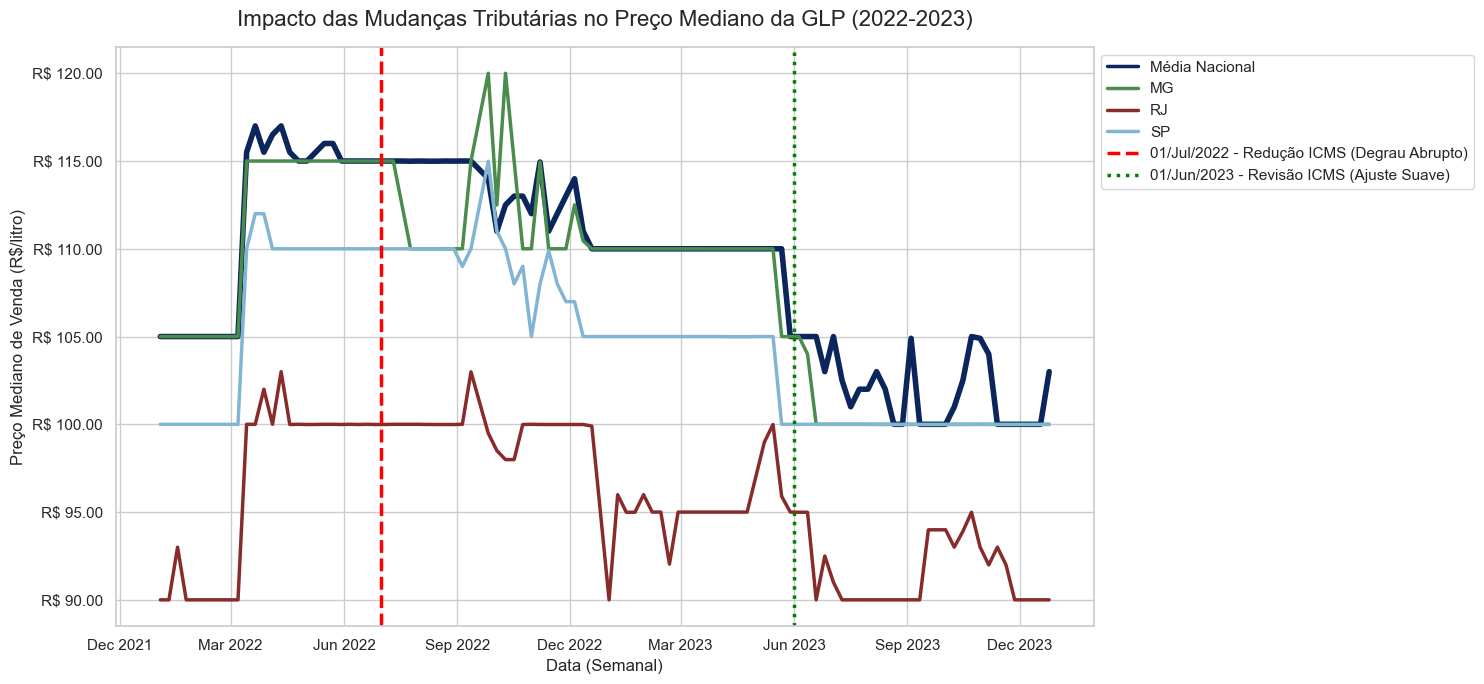

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Preparação da Data
# Converte a coluna dt_week (se for Period) para timestamp para o gráfico de linhas funcionar
if pd.api.types.is_period_dtype(df['dt_week']):
    df['data_plot'] = df['dt_week'].dt.start_time
else:
    df['data_plot'] = pd.to_datetime(df['dt_week'])

# 2. Filtrar o Período e o Produto
# Considerando apenas 2022 e 2023 e filtrando apenas a Gasolina Comum
df_filtro = df[
    (df['data_plot'].dt.year.isin([2022, 2023])) & 
    (df['Produto'] == 'GLP') # Ajuste o nome do produto exatamente como está na sua base
].copy()

# 3. Calcular as Médias (Nacional e por Estados-Chave)
# Média Nacional
df_nacional = df_filtro.groupby('data_plot', as_index=False)['price_sale_median'].median()
df_nacional['Local'] = 'Média Nacional'

# Média por Estados (SP, RJ e MG)
estados_chave = ['SP', 'RJ', 'MG']
df_estados = df_filtro[df_filtro['Estado - Sigla'].isin(estados_chave)]
df_estados_agrupado = df_estados.groupby(['data_plot', 'Estado - Sigla'], as_index=False)['price_sale_median'].median()
df_estados_agrupado.rename(columns={'Estado - Sigla': 'Local'}, inplace=True)

# Unir os dados para o plot
df_plot = pd.concat([df_nacional, df_estados_agrupado], ignore_index=True)

# 4. Configuração do Gráfico
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

# Define a paleta de cores para destacar a Média Nacional
cores = {'Média Nacional': '#0b265c', 'SP': '#82b5d4', 'RJ': '#872b2b', 'MG': '#498c4b'}

# Plotar as linhas
ax = sns.lineplot(
    data=df_plot, 
    x='data_plot', 
    y='price_sale_median', 
    hue='Local',
    linewidth=2.5,
    palette=cores
)

# Aumenta a espessura exclusiva da linha Nacional para dar destaque
plt.setp(ax.lines[0], linewidth=4)

# 5. Adicionar as Linhas Verticais (Eventos Tributários)
# Lei Complementar 194/2022 (Redução de ICMS)
data_reducao = pd.to_datetime('2022-07-01')
plt.axvline(x=data_reducao, color='red', linestyle='--', linewidth=2.5, 
            label='01/Jul/2022 - Redução ICMS (Degrau Abrupto)')

# Retorno Parcial do ICMS (Novo modelo ad rem)
data_aumento = pd.to_datetime('2023-06-01')
plt.axvline(x=data_aumento, color='green', linestyle=':', linewidth=2.5, 
            label='01/Jun/2023 - Revisão ICMS (Ajuste Suave)')

# 6. Estilização, Textos e Eixos
plt.title('Impacto das Mudanças Tributárias no Preço Mediano da GLP (2022-2023)', fontsize=16, pad=15)
plt.xlabel('Data (Semanal)', fontsize=12)
plt.ylabel('Preço Mediano de Venda (R$/litro)', fontsize=12)

# Formatar o eixo Y como moeda (R$)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:.2f}"))

# Formatar o eixo X para mostrar os meses de forma mais limpa
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Posicionar a legenda fora do gráfico para não cobrir as linhas
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11)

plt.tight_layout()
plt.show()

# Limpar coluna temporária do df original
# df_dummy.drop(columns=['data_plot'], errors='ignore', inplace=True)

In [11]:
df_dummy.index = df_dummy["dt_week"]
df_dummy = df_dummy.drop(columns=["dt_week", 'High_BZ=F',
       'Low_BZ=F', 'Open_BZ=F', 'Volume_BZ=F'])

### Validando os novos ranges, antes de aplicar o treinamento

In [12]:
# Validando os novos ranges
df_train = df[(df.index.year >= 2016) & ((df.index.year <= 2024))]

df_val = df[(df.index.year == 2025) & (df.index.month <= 8)]

df_test = df[((df.index.year >= 2025) & (df.index.month >= 9)) | 
                   ((df.index.year >= 2026) & (df.index.month <= 8))]

dataframes = {
    "Treino": df_train,
    "Validação": df_val,
    "Teste": df_test
}

for nome, _df in dataframes.items():
    print(f"\n--- Base de {nome} ---")
    
    # Observe o uso de aspas simples ('') dentro dos colchetes 
    # para não conflitar com as aspas duplas ("") da f-string
    print(f"MÉDIA:\n{_df.groupby(['Produto'])['price_sale_median'].mean()}\n")
    print(f"MEDIANA:\n{_df.groupby(['Produto'])['price_sale_median'].median()}\n")
    print(f"STD:\n{_df.groupby(['Produto'])['price_sale_median'].std()}\n")


--- Base de Treino ---
MÉDIA:
Produto
DIESEL       4.492854
ETANOL       3.931697
GASOLINA     4.949443
GLP         84.102055
Name: price_sale_median, dtype: float64

MEDIANA:
Produto
DIESEL       3.813
ETANOL       3.720
GASOLINA     4.690
GLP         78.500
Name: price_sale_median, dtype: float64

STD:
Produto
DIESEL       1.355714
ETANOL       0.864267
GASOLINA     1.038124
GLP         22.259087
Name: price_sale_median, dtype: float64


--- Base de Validação ---
MÉDIA:
Produto
DIESEL        6.296175
ETANOL        4.753233
GASOLINA      6.417825
GLP         111.173497
Name: price_sale_median, dtype: float64

MEDIANA:
Produto
DIESEL        6.235
ETANOL        4.790
GASOLINA      6.370
GLP         110.000
Name: price_sale_median, dtype: float64

STD:
Produto
DIESEL       0.444013
ETANOL       0.400445
GASOLINA     0.395506
GLP         10.274565
Name: price_sale_median, dtype: float64


--- Base de Teste ---
MÉDIA:
Produto
DIESEL        6.582820
ETANOL        4.907311
GASOLINA      6.5

In [13]:
# O baseline não é um modelo treinado — é uma regra ingênua
y_true = df_test['price_sale_median']
y_pred_baseline = df_test['price_sale_median_lag_1']

mae_baseline  = (y_pred_baseline - y_true).abs().mean()
rmse_baseline = ((y_pred_baseline - y_true) ** 2).mean() ** 0.5

print(f"MAE baseline:  {mae_baseline:.4f}")
print(f"RMSE baseline: {rmse_baseline:.4f}")

MAE baseline:  0.3204
RMSE baseline: 1.0748


In [14]:
for produto in ['GASOLINA', 'ETANOL', 'DIESEL', 'GLP']:
    dados = df_test[df_test['Produto'] == produto]
    mae = (dados['price_sale_median_lag_1'] - dados['price_sale_median']).abs().mean()
    print(f"{produto:<12} MAE baseline: {mae:.4f}")

GASOLINA     MAE baseline: 0.0597
ETANOL       MAE baseline: 0.0552
DIESEL       MAE baseline: 0.0815
GLP          MAE baseline: 1.0851


O que os números revelam:

| Produto | MAE baseline | Preço médio (teste) |  Erro relativo |
|---------|--------------|---------------------|----------------|
| GASOLINA|     0.0597   |       6.57          |         ~0.9%     |
| ETANOL  |     0.0552   |       4.91          |         ~1.1%     |
| DIESEL  |     0.0815   |       6.58          |         ~1.2%     |
| GLP     |     1.0851   |       115.11        |         ~0.9%     |

Interessante — quando você normaliza pelo preço médio de cada produto, o erro relativo do baseline fica bem parecido entre todos (0.9% a 1.2%). Isso faz sentido: o lag_1 como baseline captura bem a inércia de curto prazo em qualquer escala, porque o preço de uma semana para outra realmente não costuma variar muito em termos percentuais — para nenhum dos produtos.

### Aplicando o tratamento

regua de referencia, para validar se nao está ocorrendo um overfitting ou data leakage:
- GASOLINA:  bater MAE < 0.0597
- ETANOL:    bater MAE < 0.0552
- DIESEL:    bater MAE < 0.0815
- GLP:       bater MAE < 1.0851

In [15]:
df_train = df_dummy[(df_dummy.index.year >= 2016) & ((df_dummy.index.year <= 2025) & (df_dummy.index.month <= 4))]

df_val = df_dummy[(df_dummy.index.year == 2025) & (df_dummy.index.month <= 5) & (df_dummy.index.month <= 8)]

df_test = df_dummy[((df_dummy.index.year >= 2025) & (df_dummy.index.month >= 9)) | 
                   ((df_dummy.index.year >= 2026) & (df_dummy.index.month <= 8))]

Descisao sobre os modelos:
Quatro modelos XGBoost independentes — um para Gasolina, um para Etanol, um para Diesel, um para GLP. Cada um usa o mesmo conjunto de features (lags, rollings, exógenas, dummies de estado), exceto os dummies de produto, que deixam de fazer sentido dentro de um modelo que já é específico daquele produto.

Vantagens dessa abordagem:

- Cada modelo otimiza na escala certa, sem um produto "sequestrar" o aprendizado
- Facilita interpretar o feature_importance separadamente — por exemplo, pode ser que o lag_27 (sazonalidade semestral) importe mais - para o GLP do que para a Gasolina
- Fica mais fácil comparar contra os baselines que você já calculou por produto

Trade-off: você treina e valida 4 vezes em vez de 1, mais trabalho de pipeline, mas isso já está praticamente pronto dado que sua estrutura de dummies permite filtrar facilmente por produto.

In [16]:
def prepara_df_produto(df, produto):
    df_produto = df[df[f'produto_{produto}'] == True].copy()
    cols_produto = [c for c in df_produto.columns if c.startswith('produto_')]
    df_produto = df_produto.drop(columns=cols_produto)
    return df_produto

# GLP
df_train_glp = prepara_df_produto(df_train, 'GLP')
df_val_glp   = prepara_df_produto(df_val, 'GLP')
df_test_glp = prepara_df_produto(df_test, 'GLP')

# GASOLINA
df_train_gasolina = prepara_df_produto(df_train, 'GASOLINA')
df_val_gasolina   = prepara_df_produto(df_val, 'GASOLINA')
df_test_gasolina = prepara_df_produto(df_test, 'GASOLINA')

# ETANOL
df_train_etanol = prepara_df_produto(df_train, 'ETANOL')
df_val_etanol   = prepara_df_produto(df_val, 'ETANOL')
df_test_etanol = prepara_df_produto(df_test, 'ETANOL')

#DIESEL

df_train_diesel = prepara_df_produto(df_train, 'DIESEL')
df_val_diesel   = prepara_df_produto(df_val, 'DIESEL')
df_test_diesel = prepara_df_produto(df_test, 'DIESEL')

In [17]:
# garantindo que as datas estejam ordenadas
df_train_glp = df_train_glp.sort_values('dt_week')#.reset_index(drop=True)
df_train_gasolina = df_train_gasolina.sort_values('dt_week').reset_index(drop=True)
df_train_etanol = df_train_etanol.sort_values('dt_week').reset_index(drop=True)
df_train_diesel = df_train_diesel.sort_values('dt_week').reset_index(drop=True)

In [18]:
cols_para_remover = ['price_sale_median',"price_sale_std","n_postos","baixa_amostra", "estado_AP", "estado_DF", 'price_sale_median_rolling_mean_2', 'rolling_std_2']  # target 

X_train = df_train_glp.drop(columns=cols_para_remover)
# y_train = df_train_glp['price_sale_median']
# Em vez de prever price_sale_median diretamente...
y_train = df_train_glp['price_sale_median'] - df_train_glp['price_sale_median_lag_1']

# O modelo aprende a prever a VARIAÇÃO, não o nível absoluto
# Na hora de reconstruir a previsão real:
# preco_previsto = lag_1 + variacao_prevista

In [19]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=8)

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f"Fold {i+1}: treino={len(train_idx)} linhas | validação={len(val_idx)} linhas")

Fold 1: treino=516 linhas | validação=516 linhas
Fold 2: treino=1032 linhas | validação=516 linhas
Fold 3: treino=1548 linhas | validação=516 linhas
Fold 4: treino=2064 linhas | validação=516 linhas
Fold 5: treino=2580 linhas | validação=516 linhas
Fold 6: treino=3096 linhas | validação=516 linhas
Fold 7: treino=3612 linhas | validação=516 linhas
Fold 8: treino=4128 linhas | validação=516 linhas


In [20]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

maes = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    modelo = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )
    modelo.fit(X_tr, y_tr)

    pred = modelo.predict(X_val)
    mae = mean_absolute_error(y_val, pred)
    maes.append(mae)

print(f"MAE médio nas dobras: {sum(maes)/len(maes):.4f}")
print(f"MAE por fold: {[round(m,4) for m in maes]}")

MAE médio nas dobras: 1.6486
MAE por fold: [1.4388, 1.4158, 0.9156, 1.4486, 2.7511, 2.7551, 1.1068, 1.3571]


In [21]:
for i, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    periodo_treino = df_train_glp.iloc[train_idx].index
    periodo_val    = df_train_glp.iloc[val_idx].index
    
    print(f"\nFold {i+1}")
    print(f"  Treino: {periodo_treino.min()} até {periodo_treino.max()}")
    print(f"  Valid.: {periodo_val.min()} até {periodo_val.max()}")


Fold 1
  Treino: 2015-12-28/2016-01-03 até 2017-01-09/2017-01-15
  Valid.: 2017-01-09/2017-01-15 até 2018-01-22/2018-01-28

Fold 2
  Treino: 2015-12-28/2016-01-03 até 2018-01-22/2018-01-28
  Valid.: 2018-01-22/2018-01-28 até 2019-02-04/2019-02-10

Fold 3
  Treino: 2015-12-28/2016-01-03 até 2019-02-04/2019-02-10
  Valid.: 2019-02-04/2019-02-10 até 2020-02-17/2020-02-23

Fold 4
  Treino: 2015-12-28/2016-01-03 até 2020-02-17/2020-02-23
  Valid.: 2020-02-17/2020-02-23 até 2021-03-01/2021-03-07

Fold 5
  Treino: 2015-12-28/2016-01-03 até 2021-03-01/2021-03-07
  Valid.: 2021-03-01/2021-03-07 até 2022-03-14/2022-03-20

Fold 6
  Treino: 2015-12-28/2016-01-03 até 2022-03-14/2022-03-20
  Valid.: 2022-03-14/2022-03-20 até 2023-03-27/2023-04-02

Fold 7
  Treino: 2015-12-28/2016-01-03 até 2023-03-27/2023-04-02
  Valid.: 2023-03-27/2023-04-02 até 2024-04-08/2024-04-14

Fold 8
  Treino: 2015-12-28/2016-01-03 até 2024-04-08/2024-04-14
  Valid.: 2024-04-08/2024-04-14 até 2025-04-21/2025-04-27


In [22]:
maes = [1.4388, 1.4158, 0.9156, 1.4486, 2.7511, 2.7551, 1.1068, 1.3571]
maes_sem_choque = [m for i, m in enumerate(maes) if i not in [4, 5]]  # remove fold 5 e 6 (índice 4 e 5)

print(f"MAE médio COM choque:  {sum(maes)/len(maes):.4f}")
print(f"MAE médio SEM choque:  {sum(maes_sem_choque)/len(maes_sem_choque):.4f}")

MAE médio COM choque:  1.6486
MAE médio SEM choque:  1.2805


In [23]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importancias.head(15))

Close_BZ=F                           0.098710
estado_MT                            0.055011
price_sale_median_rolling_mean_4     0.050749
estado_MA                            0.048218
price_sale_median_lag_2              0.042930
rolling_std_4                        0.040996
price_sale_median_lag_1              0.039482
price_sale_median_rolling_mean_12    0.039401
price_sale_median_lag_4              0.036652
estado_RJ                            0.035642
estado_PR                            0.033870
estado_AM                            0.031460
rolling_std_12                       0.030866
estado_RO                            0.029599
price_sale_median_rolling_mean_8     0.029089
dtype: float32


# Resumo — Preparação e Diagnóstico do Modelo (GLP)

## 1. Escopo e granularidade
- Modelo segmentado por **produto** (GLP, Gasolina, Etanol, Diesel) — modelos independentes, não um único modelo unificado, dado que as escalas de preço são muito diferentes entre produtos.
- Granularidade **semanal**, agregada por mediana de `Valor de Venda` por `Estado - Sigla` × `Produto` × `dt_week`.
- Segmentação mantida por **estado individual** (não por região), com base em evidência estatística (teste de Kruskal-Wallis + post-hoc de Dunn) de que estados diferem significativamente entre si.

## 2. Tratamento da série temporal
- Reindex de todas as combinações estado × produto para as 909 semanas do período, com `ffill` segmentado por grupo (nunca global) para preencher gaps — gaps identificados como pontuais (~1 semana em média), não estruturais.
- Feature `price_sale_std` (dispersão entre postos) e `n_postos` (cobertura amostral) adicionadas; casos de `n_postos = 1` tratados com `fillna(0)` + flag `baixa_amostra`, não ffill (natureza estatística diferente de gap temporal).

## 3. Corte temporal do treino — decisão fundamentada
- Teste de correlação de Spearman entre `price_sale_median` e `Close_BZ=F` (Brent) por sub-período revelou **quebra estrutural de regime**:
  - Antes de 2015: correlação fraca/negativa (-0.06 a -0.23)
  - 2016 em diante: correlação forte e positiva (+0.64 a +0.78)
  - Explicação: mudança da política de preços da Petrobras (de preços administrados para Política de Paridade de Importação, PPI, a partir de 2016).
- **Decisão:** treino cortado para iniciar em 2016-01, descartando 2007-2015 por não representar mais o regime de mercado vigente.

## 4. Divisão treino / validação / teste
```
Treino:      2016-01 até 2025-04
Validação:   2025-05 até 2025-08
Teste final: 2025-09 até 2026-08
```
- Ajustado para dar mais peso a dados recentes (patamar de preço atual), preservando um bloco de validação e um teste final intocado.

## 5. Baseline ingênuo (referência mínima de qualidade)
- Baseline = `price_sale_median_lag_1` (preço da semana anterior) como previsão.
- MAE do baseline por produto (base de teste):
  - Gasolina: 0.0597 | Etanol: 0.0552 | Diesel: 0.0815 | **GLP: 1.0851**

## 6. Validação cruzada temporal (TimeSeriesSplit, 8 folds)
- Identificados 2 folds com MAE muito acima dos demais (Fold 5 e 6), coincidindo com choques de mercado documentados (pandemia 2020-2021, guerra Rússia-Ucrânia 2022) — explicação plausível, não erro de pipeline.
- MAE médio COM esses folds: instável e elevado; SEM eles: mais próximo do esperado — confirma que o modelo é razoável em condições normais e mais fraco em choques extremos (comportamento esperado de qualquer modelo baseado em histórico).

## 7. Diagnóstico via feature_importance — problema identificado e corrigido
- **Problema:** modelo inicial concentrava >90% da importância em `lag_1` e `rolling_mean_2/4` — ignorando quase completamente as variáveis exógenas (dólar, Brent, PIB) validadas estatisticamente como preditoras fortes.
- **Causa:** features de curtíssimo prazo (lag/rolling) explicam a maior parte da variância local, reduzindo o incentivo do XGBoost a usar variáveis mais lentas/estruturais.
- **Correção aplicada:** mudança do target de `price_sale_median` (nível absoluto) para o **resíduo** `price_sale_median - price_sale_median_lag_1`. Isso impede o modelo de "se esconder" atrás do lag, forçando-o a explicar a variação usando as demais features.
- **Resultado:** Close_BZ=F (Brent) passou a ser a feature mais importante (~10%); importância mais distribuída entre lags, rollings e estados. MAE melhorou em quase todos os folds, com maior ganho justamente no fold de choque mais extremo (-43%).

## 8. Situação atual
```
Baseline ingênuo:      MAE = 1.0851
Modelo (resíduo) COM choque:  MAE = 1.6486
Modelo (resíduo) SEM choque:  MAE = 1.2805
```
Ainda acima do baseline, mas a lacuna diminuiu de forma consistente a cada ajuste. Próximo passo: calibração de hiperparâmetros via **Optuna** (busca bayesiana, TPE sampler), otimizando o MAE reconstruído na escala real do preço (`lag_1 + resíduo_previsto`), usando a mesma estrutura de `TimeSeriesSplit` já validada.

## 9. Próximos passos após o Optuna
- Avaliar se o modelo calibrado supera o baseline nos folds "normais".
- Repetir o pipeline para os demais produtos (Gasolina, Etanol, Diesel).
- Avaliação final única no bloco de teste (2025-09 a 2026-08).

In [24]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

def objetivo(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800, step=100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 7),
        'random_state': 42
    }

    maes_fold = []
    X_train_v2 = X_train
    y_train_v2 = y_train

    for train_idx, val_idx in tscv.split(X_train_v2):
        X_tr, X_val = X_train_v2.iloc[train_idx], X_train_v2.iloc[val_idx]
        y_tr, y_val = y_train_v2.iloc[train_idx], y_train_v2.iloc[val_idx]

        modelo = XGBRegressor(**params)
        modelo.fit(X_tr, y_tr)

        pred_residuo = modelo.predict(X_val)

        # Reconstrói a previsão na escala real do preço
        lag1_val    = df_train_glp.iloc[val_idx]['price_sale_median_lag_1'].values
        preco_real  = df_train_glp.iloc[val_idx]['price_sale_median'].values
        preco_pred  = lag1_val + pred_residuo

        mae = mean_absolute_error(preco_real, preco_pred)
        maes_fold.append(mae)

    return np.mean(maes_fold)

study = optuna.create_study(direction='minimize')
study.optimize(objetivo, n_trials=50)

print("Melhores hiperparâmetros:", study.best_params)
print("Melhor MAE (escala real):", study.best_value)

c:\Users\ferna\anaconda3\envs\main\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-19 00:13:48,772] A new study created in memory with name: no-name-2a34a3ed-8768-464b-a46a-c9f50b837e6b
[I 2026-08-19 00:13:52,366] Trial 0 finished with value: 1.4690836164642076 and parameters: {'max_depth': 3, 'learning_rate': 0.03832580268343921, 'n_estimators': 700, 'subsample': 0.8119408299821785, 'colsample_bytree': 0.969277132458857, 'min_child_weight': 6}. Best is trial 0 with value: 1.4690836164642076.
[I 2026-08-19 00:13:58,841] Trial 1 finished with value: 1.6744883285011403 and parameters: {'max_depth': 6, 'learning_rate': 0.10014997645017329, 'n_estimators': 700, 'subsample': 0.5552154063830274, 'colsample_bytree': 0.6981913135627726, 'min_child_weight': 2}. Best is trial 0 with value: 1.4690836164642076.
[I 

Melhores hiperparâmetros: {'max_depth': 4, 'learning_rate': 0.011577654339934886, 'n_estimators': 200, 'subsample': 0.5384698542256263, 'colsample_bytree': 0.5791398300641212, 'min_child_weight': 6}
Melhor MAE (escala real): 1.2076450067036943


In [25]:
# Reproduz os MAEs por fold com os melhores hiperparâmetros do Optuna
melhores_params = study.best_params
melhores_params['random_state'] = 42

maes_fold_final = []
X_train_v2 = X_train
y_train_v2 = y_train
for train_idx, val_idx in tscv.split(X_train_v2):
    X_tr, X_val = X_train_v2.iloc[train_idx], X_train_v2.iloc[val_idx]
    y_tr, y_val = y_train_v2.iloc[train_idx], y_train_v2.iloc[val_idx]

    modelo = XGBRegressor(**melhores_params)
    modelo.fit(X_tr, y_tr)

    pred_residuo = modelo.predict(X_val)
    lag1_val   = df_train_glp.iloc[val_idx]['price_sale_median_lag_1'].values
    preco_real = df_train_glp.iloc[val_idx]['price_sale_median'].values
    preco_pred = lag1_val + pred_residuo

    mae = mean_absolute_error(preco_real, preco_pred)
    maes_fold_final.append(mae)

print("MAE por fold:", [round(m, 4) for m in maes_fold_final])

maes_sem_choque = [m for i, m in enumerate(maes_fold_final) if i not in [4, 5]]
print(f"MAE médio SEM choque: {sum(maes_sem_choque)/len(maes_sem_choque):.4f}")

MAE por fold: [1.014, 0.9344, 0.7288, 1.0499, 1.5361, 2.2621, 1.014, 1.1219]
MAE médio SEM choque: 0.9772


In [26]:
# Aplicando no treino final
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

melhores_params = study.best_params
melhores_params['random_state'] = 42

modelo_final_glp = XGBRegressor(**melhores_params)
modelo_final_glp.fit(X_train_v2, y_train_v2)  # treino completo, sem CV agora

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5791398300641212, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.011577654339934886,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=6, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, ...)

In [27]:
X_val = df_val_glp.drop(columns=cols_para_remover)
y_val_real = df_val_glp['price_sale_median']
lag1_val   = df_val_glp['price_sale_median_lag_1']

In [28]:
pred_residuo_val = modelo_final_glp.predict(X_val)
pred_preco_val    = lag1_val + pred_residuo_val

mae_val  = mean_absolute_error(y_val_real, pred_preco_val)
rmse_val = mean_squared_error(y_val_real, pred_preco_val) ** 0.5

print(f"MAE validação:  {mae_val:.4f}")
print(f"RMSE validação: {rmse_val:.4f}")

MAE validação:  1.0285
RMSE validação: 1.8988


In [29]:
mae_baseline_val = (lag1_val - y_val_real).abs().mean()
print(f"MAE baseline (validação): {mae_baseline_val:.4f}")
print(f"MAE modelo (validação):   {mae_val:.4f}")

melhora = (1 - mae_val / mae_baseline_val) * 100
print(f"Melhora sobre baseline: {melhora:+.1f}%")

MAE baseline (validação): 0.9990
MAE modelo (validação):   1.0285
Melhora sobre baseline: -3.0%


In [30]:
print("Desvio padrão do preço na validação:", df_val_glp['price_sale_median'].std())
print("Desvio padrão do preço no treino:", df_train_glp['price_sale_median'].std())

variacao_val = df_val_glp.sort_values('dt_week')['price_sale_median'].diff().abs().mean()
variacao_train = df_train_glp.sort_values('dt_week')['price_sale_median'].diff().abs().mean()

print(f"Variação média semana a semana (validação): {variacao_val:.4f}")
print(f"Variação média semana a semana (treino):    {variacao_train:.4f}")

Desvio padrão do preço na validação: 10.489511026729792
Desvio padrão do preço no treino: 22.769002638004935
Variação média semana a semana (validação): 12.0251
Variação média semana a semana (treino):    9.2553


In [31]:
df_val_glp['erro_modelo']    = (pred_preco_val - y_val_real).abs()
df_val_glp['erro_baseline']  = (lag1_val - y_val_real).abs()
df_val_glp['modelo_pior']    = df_val_glp['erro_modelo'] > df_val_glp['erro_baseline']

print(f"% de casos onde o modelo foi pior que o baseline: {df_val_glp['modelo_pior'].mean()*100:.1f}%")

# Por semana
por_semana = df_val_glp.groupby('dt_week')[['erro_modelo', 'erro_baseline']].mean()
print(por_semana)

% de casos onde o modelo foi pior que o baseline: 73.5%
                       erro_modelo  erro_baseline
dt_week                                          
2024-12-30/2025-01-05     0.972312       0.967037
2025-01-06/2025-01-12     1.501479       1.538333
2025-01-13/2025-01-19     0.832617       0.848519
2025-01-20/2025-01-26     0.965200       0.939630
2025-01-27/2025-02-02     1.326544       1.324630
2025-02-03/2025-02-09     1.870265       1.919074
2025-02-10/2025-02-16     1.116327       1.053704
2025-02-17/2025-02-23     1.667977       1.665370
2025-02-24/2025-03-02     1.762224       1.794259
2025-03-03/2025-03-09     0.836122       0.777963
2025-03-10/2025-03-16     0.839276       0.832037
2025-03-17/2025-03-23     0.647517       0.592778
2025-03-24/2025-03-30     0.922764       0.868148
2025-03-31/2025-04-06     0.623285       0.552222
2025-04-07/2025-04-13     0.780272       0.751852
2025-04-14/2025-04-20     0.764293       0.682407
2025-04-21/2025-04-27     1.002555       0.9

In [32]:
COLUNAS_REMOVER = [
    'price_sale_median', 'price_sale_std', 'n_postos', 'baixa_amostra',
    'estado_AP', 'estado_DF',
    'price_sale_median_rolling_mean_2', 'rolling_std_2'
]

def prepara_X_y(df, colunas_remover=COLUNAS_REMOVER):
    X = df.drop(columns=colunas_remover, errors='ignore')
    y = df['price_sale_median']
    lag1 = df['price_sale_median_lag_1']
    return X, y, lag1

In [33]:
X_teste, y_teste_real, lag1_teste = prepara_X_y(df_test_glp)

pred_residuo_teste = modelo_final_glp.predict(X_teste)
pred_preco_teste    = lag1_teste + pred_residuo_teste

mae_teste  = mean_absolute_error(y_teste_real, pred_preco_teste)
rmse_teste = mean_squared_error(y_teste_real, pred_preco_teste) ** 0.5

mae_baseline_teste = (lag1_teste - y_teste_real).abs().mean()

print(f"MAE baseline (teste):  {mae_baseline_teste:.4f}")
print(f"MAE modelo (teste):    {mae_teste:.4f}")
print(f"RMSE modelo (teste):   {rmse_teste:.4f}")

melhora = (1 - mae_teste / mae_baseline_teste) * 100
print(f"Melhora sobre baseline: {melhora:+.1f}%")

MAE baseline (teste):  1.0851
MAE modelo (teste):    1.1446
RMSE modelo (teste):   2.0939
Melhora sobre baseline: -5.5%


In [34]:
df_test_glp.index

PeriodIndex(['2025-09-01/2025-09-07', '2025-09-08/2025-09-14',
             '2025-09-15/2025-09-21', '2025-09-22/2025-09-28',
             '2025-09-29/2025-10-05', '2025-10-06/2025-10-12',
             '2025-10-13/2025-10-19', '2025-10-20/2025-10-26',
             '2025-10-27/2025-11-02', '2025-11-03/2025-11-09',
             ...
             '2026-05-25/2026-05-31', '2026-06-01/2026-06-07',
             '2026-06-08/2026-06-14', '2026-06-15/2026-06-21',
             '2026-06-22/2026-06-28', '2026-06-29/2026-07-05',
             '2026-07-06/2026-07-12', '2026-07-13/2026-07-19',
             '2026-07-20/2026-07-26', '2026-07-27/2026-08-02'],
            dtype='period[W-SUN]', name='dt_week', length=1296)

In [35]:
df_test_glp['erro_modelo']   = (pred_preco_teste - y_teste_real).abs()
df_test_glp['erro_baseline'] = (lag1_teste - y_teste_real).abs()

print(f"% de casos onde o modelo foi pior: {(df_test_glp['erro_modelo'] > df_test_glp['erro_baseline']).mean()*100:.1f}%")

por_mes = (
    df_test_glp
    .groupby(df_test_glp.index.astype('period[M]'))
    [['erro_modelo', 'erro_baseline']]
    .mean()
)

print(por_mes)


% de casos onde o modelo foi pior: 75.3%
         erro_modelo  erro_baseline
dt_week                            
2025-09     1.165117       1.135463
2025-10     0.685790       0.625139
2025-11     0.938697       0.871704
2025-12     1.075001       1.038889
2026-01     0.979431       0.891806
2026-02     1.925884       1.904954
2026-03     0.981638       0.905037
2026-04     1.623770       1.522315
2026-05     1.391385       1.267370
2026-06     1.327150       1.321389
2026-07     0.585121       0.554630
2026-08     0.910885       0.887037


In [36]:
df_test_glp[["price_sale_median"]]

,price_sale_median
dt_week,
2025-09-01/2025-09-07,122.0
2025-09-08/2025-09-14,122.0
2025-09-15/2025-09-21,123.0
2025-09-22/2025-09-28,124.0
2025-09-29/2025-10-05,124.0
...,...
2026-06-29/2026-07-05,135.0
2026-07-06/2026-07-12,134.0
2026-07-13/2026-07-19,135.0


In [37]:
df_resultado = df_test_glp.copy()
df_resultado['estado'] = df_test_glp.filter(like='estado_').idxmax(axis=1).str.replace('estado_', '')
df_resultado['preco_real']      = y_teste_real.values
df_resultado['preco_previsto']  = pred_preco_teste
df_resultado['preco_baseline']  = lag1_teste.values
df_resultado['erro_modelo']     = (df_resultado['preco_previsto'] - df_resultado['preco_real']).abs()
df_resultado['erro_baseline']   = (df_resultado['preco_baseline'] - df_resultado['preco_real']).abs()

df_resultado.head(2)

,price_sale_median,price_sale_std,n_postos,baixa_amostra,price_sale_median_lag_1,price_sale_median_lag_2,price_sale_median_lag_3,price_sale_median_lag_4,price_sale_median_lag_8,price_sale_median_lag_27,...,estado_SC,estado_SE,estado_SP,estado_TO,erro_modelo,erro_baseline,estado,preco_real,preco_previsto,preco_baseline
dt_week,,,,,,,,,,,,,,,,,,,,,
2025-09-01/2025-09-07,122.0,6.095956,260.0,0,122.0,122.0,125.0,122.0,123.0,125.0,...,False,False,False,False,0.121220,0.0,AC,122.0,122.121220,122.0
2025-09-08/2025-09-14,122.0,6.095956,260.0,0,122.0,122.0,122.0,125.0,122.0,124.5,...,False,False,False,False,0.145617,0.0,AC,122.0,122.145617,122.0


In [38]:
colunas_extra = ['erro_modelo', 'erro_baseline']
df_teste_glp_limpo = df_test_glp.drop(columns=colunas_extra, errors='ignore')

In [39]:
def prever_proximas_semanas(df_historico, estado, modelo, n_semanas=3):
    """
    df_historico: dataframe já no formato de features (com dummies, exógenas, etc.),
                  ordenado por dt_week, contendo o histórico mais recente do estado.
    """
    historico = df_historico[df_historico[f'estado_{estado}'] == True].sort_index().copy()
    
    previsoes = []
    
    for i in range(n_semanas):
        ultima_linha = historico.iloc[-1:].copy()
        
        # Monta a nova linha de features com base no histórico mais recente
        nova_linha = ultima_linha.copy()
        
        nova_linha['price_sale_median_lag_1'] = historico['price_sale_median'].iloc[-1]
        nova_linha['price_sale_median_lag_2'] = historico['price_sale_median'].iloc[-2]
        nova_linha['price_sale_median_lag_3'] = historico['price_sale_median'].iloc[-3]
        nova_linha['price_sale_median_lag_4'] = historico['price_sale_median'].iloc[-4]
        nova_linha['price_sale_median_lag_8'] = historico['price_sale_median'].iloc[-8]
        nova_linha['price_sale_median_lag_27'] = historico['price_sale_median'].iloc[-27]
        
        nova_linha['price_sale_median_rolling_mean_4']  = historico['price_sale_median'].iloc[-4:].mean()
        nova_linha['rolling_std_4']                      = historico['price_sale_median'].iloc[-4:].std()
        nova_linha['price_sale_median_rolling_mean_8']  = historico['price_sale_median'].iloc[-8:].mean()
        nova_linha['rolling_std_8']                      = historico['price_sale_median'].iloc[-8:].std()
        nova_linha['price_sale_median_rolling_mean_12'] = historico['price_sale_median'].iloc[-12:].mean()
        nova_linha['rolling_std_12']                     = historico['price_sale_median'].iloc[-12:].std()
        
        # Exógenas: mantém o último valor conhecido (você não tem dólar/Brent futuro real)
        # já estão em nova_linha por causa do ultima_linha.copy()
        
        # próxima semana, definida como o novo índice
        nova_period = historico.index[-1] + 1
        nova_linha.index = [nova_period]
        
        X_nova, _, lag1_nova = prepara_X_y(
            nova_linha.assign(price_sale_median=0),
            colunas_remover=COLUNAS_REMOVER
        )
        
        residuo_previsto = modelo.predict(X_nova)[0]
        preco_previsto = nova_linha['price_sale_median_lag_1'].values[0] + residuo_previsto
        
        nova_linha['price_sale_median'] = preco_previsto
        previsoes.append(nova_linha[['price_sale_median']])
        
        historico = pd.concat([historico, nova_linha])
        
    return pd.concat(previsoes)

In [40]:
previsoes_sp = prever_proximas_semanas(df_teste_glp_limpo, estado='SP', modelo=modelo_final_glp, n_semanas=3)
print(previsoes_sp)

                       price_sale_median
2026-08-03/2026-08-09         115.041421
2026-08-10/2026-08-16         115.080490
2026-08-17/2026-08-23         115.119559


In [41]:
def backtest_horizonte(df_teste_glp, estado, modelo, n_semanas=3, n_janelas=10):
    resultados = []
    historico_completo = df_teste_glp[df_teste_glp[f'estado_{estado}'] == True].sort_index()
    
    # Escolhe pontos de partida espalhados ao longo do teste
    indices_partida = range(30, len(historico_completo) - n_semanas, 
                             max(1, (len(historico_completo) - 30 - n_semanas) // n_janelas))
    
    for idx in indices_partida:
        historico_ate_aqui = historico_completo.iloc[:idx]
        valores_reais = historico_completo['price_sale_median'].iloc[idx:idx+n_semanas].values
        
        previsao = prever_proximas_semanas(historico_ate_aqui, estado, modelo, n_semanas)
        
        for h in range(n_semanas):
            erro_pct = abs(previsao['price_sale_median'].iloc[h] - valores_reais[h]) / valores_reais[h]
            resultados.append({'horizonte': h+1, 'mape': erro_pct})
    
    return pd.DataFrame(resultados)

df_backtest = backtest_horizonte(df_teste_glp_limpo, 'SP', modelo_final_glp, n_semanas=3, n_janelas=15)
mape_por_horizonte = df_backtest.groupby('horizonte')['mape'].mean() * 100
print(mape_por_horizonte)

horizonte
1    0.636014
2    0.953000
3    1.256670
Name: mape, dtype: float64


In [ ]:

# y_train = df_train_glp['price_sale_median']
# Em vez de prever price_sale_median diretamente...


In [44]:
X_train = df_train_diesel.drop(columns=cols_para_remover)
y_train = df_train_diesel['price_sale_median'] - df_train_diesel['price_sale_median_lag_1']
modelo_simples_diesel = XGBRegressor(
            max_depth=6, learning_rate=0.05, n_estimators=300, random_state=42
        ).fit(X_train, y_train)
X_teste_diesel, y_teste_real_diesel, lag1_teste_diesel = prepara_X_y(df_test_diesel)
pred_residuo_teste = modelo_simples_diesel.predict(X_teste_diesel)
pred_preco_teste = lag1_teste_diesel.values + pred_residuo_teste

comparacao = pd.DataFrame({
    'real': y_teste_real_diesel.values,
    'baseline': lag1_teste_diesel.values,
    'modelo': pred_preco_teste,
    'residuo_previsto': pred_residuo_teste
})

print(comparacao.head(20))
print("\nEstatísticas do resíduo previsto:")
print(comparacao['residuo_previsto'].describe())

print("\nEstatísticas do resíduo real (o que o modelo deveria acertar):")
residuo_real = y_teste_real_diesel.values - lag1_teste_diesel.values
print(pd.Series(residuo_real).describe())

     real  baseline    modelo  residuo_previsto
0   7.495     8.170  8.165117         -0.004883
1   7.640     7.495  7.511060          0.016060
2   7.570     7.640  7.824740          0.184740
3   7.415     7.570  7.596207          0.026207
4   7.640     7.415  7.476205          0.061205
5   7.400     7.640  7.696598          0.056598
6   7.400     7.400  7.334107         -0.065893
7   7.445     7.400  7.328848         -0.071152
8   7.390     7.445  7.496464          0.051464
9   7.465     7.390  7.436766          0.046766
10  7.490     7.465  7.528226          0.063226
11  7.400     7.490  7.555485          0.065485
12  7.655     7.400  7.473660          0.073660
13  7.350     7.655  7.697113          0.042113
14  7.390     7.350  7.382951          0.032951
15  7.390     7.390  7.427724          0.037724
16  7.390     7.390  7.418897          0.028897
17  7.390     7.390  7.406922          0.016922
18  7.350     7.390  7.454024          0.064024
19  7.400     7.350  7.407536          0

In [45]:
residuo_real_train = y_train  # já é o resíduo, você calculou como price - lag1
print("Média do resíduo no TREINO:", residuo_real_train.mean())
print("Std do resíduo no TREINO:", residuo_real_train.std())

Média do resíduo no TREINO: 0.00722609819121447
Std do resíduo no TREINO: 0.11882979264589705


In [46]:
# Verifica a tendência do Brent no fim do treino vs. no teste
print("Brent - últimos 12 meses do treino:")
print(df_train_diesel['Close_BZ=F'].tail(52).describe())

print("\nBrent - período de teste:")
print(df_test_diesel['Close_BZ=F'].describe())

importancias_diesel = pd.Series(
    modelo_simples_diesel.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importancias_diesel.head(10))

Brent - últimos 12 meses do treino:
count    52.000000
mean     65.596538
std       0.696219
min      64.879997
25%      64.879997
50%      66.260002
75%      66.260002
max      66.260002
Name: Close_BZ=F, dtype: float64

Brent - período de teste:
count    1296.000000
mean       78.725417
std        17.335024
min        60.560001
25%        64.717499
50%        69.090000
75%        95.105003
max       114.440002
Name: Close_BZ=F, dtype: float64
Close_BZ=F                          0.162369
ipca                                0.067804
estado_SE                           0.057578
estado_BA                           0.048422
estado_AM                           0.047916
Valor Venda Dolar                   0.047004
pib_mensal                          0.042448
price_sale_median_rolling_mean_8    0.041062
estado_AL                           0.036886
estado_AC                           0.031079
dtype: float32


In [47]:
df_train_diesel['brent_pct_change'] = df_train_diesel['Close_BZ=F'].pct_change()
df_test_diesel['brent_pct_change']  = df_test_diesel['Close_BZ=F'].pct_change()
# (cuidado: precisa ser calculado ANTES do split, sobre a série completa, 
#  senão a primeira linha do teste fica sem valor de referência do fim do treino)

testes

In [50]:
# Ordena por Estado + Produto + Semana para garantir que o pct_change 
# não misture séries diferentes
df_final_diesel = df[df['Produto'] == 'DIESEL'].sort_values(['Estado - Sigla']).sort_index()

df_final_diesel['brent_pct_change'] = (
    df_final_diesel.groupby('Estado - Sigla')['Close_BZ=F']
    .pct_change()
)

In [53]:
df_train_diesel = df_train_diesel.sort_index()  # dt_week é o índice
df_val_diesel   = df_val_diesel.sort_index()
df_test_diesel  = df_test_diesel.sort_index()

df_train_diesel['brent_pct_change'] = df_train_diesel['Close_BZ=F'].pct_change()

# Para o teste, usa o último valor do treino como referência do primeiro ponto
ultimo_brent_treino = df_train_diesel['Close_BZ=F'].iloc[-1]
df_test_diesel['brent_pct_change'] = df_test_diesel['Close_BZ=F'].pct_change()
df_test_diesel.loc[df_test_diesel.index[0], 'brent_pct_change'] = (
    df_test_diesel['Close_BZ=F'].iloc[0] / ultimo_brent_treino - 1
)

df_train_diesel['brent_pct_change'] = df_train_diesel['brent_pct_change'].fillna(0)

In [54]:
cols_para_remover_v2 = cols_para_remover + ['Close_BZ=F']  # remove o valor absoluto

X_train_v3 = df_train_diesel.drop(columns=cols_para_remover_v2)
y_train_v3 = df_train_diesel['price_sale_median'] - df_train_diesel['price_sale_median_lag_1']

modelo_teste_pct = XGBRegressor(
    max_depth=6, learning_rate=0.05, n_estimators=300, random_state=42
).fit(X_train_v3, y_train_v3)

In [55]:
X_teste_v3 = df_test_diesel.drop(columns=cols_para_remover_v2)
lag1_teste_v3 = df_test_diesel['price_sale_median_lag_1']
y_teste_real_v3 = df_test_diesel['price_sale_median']

pred_residuo_v3 = modelo_teste_pct.predict(X_teste_v3)
pred_preco_v3 = lag1_teste_v3.values + pred_residuo_v3

mae_v3 = mean_absolute_error(y_teste_real_v3, pred_preco_v3)
mae_baseline_v3 = (lag1_teste_v3 - y_teste_real_v3).abs().mean()

print(f"MAE baseline: {mae_baseline_v3:.4f}")
print(f"MAE modelo (Brent como pct_change): {mae_v3:.4f}")

MAE baseline: 0.0815
MAE modelo (Brent como pct_change): 0.1357
